In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://rbi.org.in/Scripts/ATMView.aspx?atmid=166"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table")

rows = []
for tr in table.find_all("tr"):
    cells = tr.find_all(["th", "td"])
    row = [cell.get_text(strip=True) for cell in cells]
    rows.append(row)

df = pd.DataFrame(rows)




#Data Wrangling

In [ ]:
df = df.iloc[11:].reset_index(drop=True)


In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,...,1915,1916,1917,1918,1919,1920,1921,1922,1923,1924,1925,1926,1927,1928,1929
0,1,BANK OF BARODA,8395,2383,47037,44909,22566,2295417,2937896,87335032,6803577,13816828,3172968,16982670,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,2,BANK OF INDIA,5339,2897,18184,21901,0,1227145,73696,38747535,141428,616391,66297,318385,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,3,BANK OF MAHARASHTRA,2173,243,1391,3773,355014,927987,31278,14022969,46320,213119,19055,99470,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,4,CANARA BANK,8217,3809,74536,13177,0,3344640,997943,59396108,1114470,4372177,469173,2707241,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,5,CENTRAL BANK OF INDIA,2857,1144,3344,2755,34434,1959821,0,28178425,0,0,0,0,0,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [ ]:
df = df.iloc[:, :28]
pd.set_option('display.max_columns', 30)
df.head(5).iloc[:, :35]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,1,BANK OF BARODA,8395,2383,47037,44909,22566,2295417,2937896,87335032,6803577,13816828,3172968,16982670,0,0,13104,66327,3376422,8311974,402051,2567196,25,60,23739493,118048467,41,45
1,2,BANK OF INDIA,5339,2897,18184,21901,0,1227145,73696,38747535,141428,616391,66297,318385,0,0,9719,57497,2238721,4925170,451900,990956,0,0,15265108,63750511,267,266
2,3,BANK OF MAHARASHTRA,2173,243,1391,3773,355014,927987,31278,14022969,46320,213119,19055,99470,0,0,755,3744,1118280,2396278,216929,623367,5588,62020,6086661,28403102,0,0
3,4,CANARA BANK,8217,3809,74536,13177,0,3344640,997943,59396108,1114470,4372177,469173,2707241,0,0,103464,581758,5852115,16562920,914454,3890117,4172,73509,30969820,149324314,75,64
4,5,CENTRAL BANK OF INDIA,2857,1144,3344,2755,34434,1959821,0,28178425,0,0,0,0,0,0,0,0,1462407,3636026,193709,685350,0,0,8659061,40488348,3538,3626


In [ ]:
df = df.iloc[:68].reset_index(drop=True)
df.tail(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
38,37,BARCLAYS BANK PLC,0,0,0,0,1,0,0,1058,0,0,0,0,0,0,0,0,100,580,0,0,0,0,605,5574,0,0
39,38,CITI BANK,0,0,0,0,0,0,223969,0,143621,1129885,237890,4018713,0,0,603,5218,0,0,0,0,0,0,0,0,0,0
40,39,DBS INDIA BANK LTD,440,336,647,90,0,7414,508863,1739117,537559,2468444,300166,2539124,0,0,3162,9522,197333,517354,95823,315570,0,0,743589,3960854,0,0
41,40,DEUTSCHE BANK LTD,13,2,0,0,0,8,0,104832,0,0,0,0,0,0,0,0,27883,99482,13034,51965,0,0,29911,184799,0,0
42,41,DOHA BANK Q.P.S.C.,2,0,0,0,0,0,0,22614,0,0,0,0,0,0,0,0,1000,3383,240,431,0,0,2248,13664,0,0
43,42,HSBC LTD,46,27,0,0,0,0,801372,842628,1096494,4204872,1644977,15443401,0,0,3195,22258,288260,1530967,0,0,0,0,252444,1540882,0,0
44,43,KEB HANA BANK,1,0,0,0,0,0,0,1601,0,0,0,0,0,0,0,0,1126,4123,138,485,0,0,348,2305,0,0
45,44,KOOKMIN BANK,0,0,0,0,0,0,0,481,0,0,0,0,0,0,0,0,614,2612,230,452,0,0,116,711,0,0
46,45,SBM BANK INDIA LTD,0,0,0,0,0,0,693987,820325,225432,367722,427934,957436,0,0,7397,34097,9276,26656,7131,21420,0,0,28748,86118,0,0
47,46,STANDARD CHARTERED BANK LTD,101,46,0,0,0,0,928039,1029810,1120394,4261299,1169801,6374806,0,0,2172,14377,342183,1213449,146949,599237,37,706,612364,3271071,0,0


In [ ]:
df = df.drop(index=[12, 34, 49, 56]).reset_index(drop=True)


In [ ]:
df['Bank_Type'] = ''

# Convert first column to numeric (if it’s stored as string)
df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors='coerce')

df.loc[df.iloc[:, 0].between(1, 12), 'Bank_Type'] = 'Public Sector Bank'
df.loc[df.iloc[:, 0].between(13, 33), 'Bank_Type'] = 'Private Sector Bank'
df.loc[df.iloc[:, 0].between(34, 47), 'Bank_Type'] = 'Foreign Bank'
df.loc[df.iloc[:, 0].between(48, 53), 'Bank_Type'] = 'Payment Bank'
df.loc[df.iloc[:, 0].between(54, 64), 'Bank_Type'] = 'Small Finance Bank'
col_order = list(df.columns)
col_order.insert(2, col_order.pop(col_order.index('Bank_Type')))
df = df[col_order]


In [ ]:
df = df.drop(df.columns[0], axis=1)


In [ ]:
pd.set_option('display.max_rows', 100)
df.head(75)

,1,Bank_Type,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,BANK OF BARODA,Public Sector Bank,8395,2383,47037,44909,22566,2295417,2937896,87335032,6803577,13816828,3172968,16982670,0,0,13104,66327,3376422,8311974,402051,2567196,25,60,23739493,118048467,41,45
1,BANK OF INDIA,Public Sector Bank,5339,2897,18184,21901,0,1227145,73696,38747535,141428,616391,66297,318385,0,0,9719,57497,2238721,4925170,451900,990956,0,0,15265108,63750511,267,266
2,BANK OF MAHARASHTRA,Public Sector Bank,2173,243,1391,3773,355014,927987,31278,14022969,46320,213119,19055,99470,0,0,755,3744,1118280,2396278,216929,623367,5588,62020,6086661,28403102,0,0
3,CANARA BANK,Public Sector Bank,8217,3809,74536,13177,0,3344640,997943,59396108,1114470,4372177,469173,2707241,0,0,103464,581758,5852115,16562920,914454,3890117,4172,73509,30969820,149324314,75,64
4,CENTRAL BANK OF INDIA,Public Sector Bank,2857,1144,3344,2755,34434,1959821,0,28178425,0,0,0,0,0,0,0,0,1462407,3636026,193709,685350,0,0,8659061,40488348,3538,3626
5,INDIAN BANK,Public Sector Bank,4617,607,20921,13292,0,2867071,282514,33020751,238832,1055577,269017,1347319,0,0,4777,36844,2998465,7125558,559298,1339331,158,494,19223516,91525693,1479,1489
6,INDIAN OVERSEAS BANK,Public Sector Bank,2764,737,0,9041,0,434804,65086,20478463,79359,250667,25487,100885,0,0,2658,13563,2278214,5157939,391387,953459,0,0,12214319,51422876,0,0
7,PUNJAB AND SIND BANK,Public Sector Bank,1016,27,958,1665,1104,163637,0,3480941,0,0,0,0,0,0,0,0,296211,777893,90694,240433,0,0,1397823,6935195,0,0
8,PUNJAB NATIONAL BANK,Public Sector Bank,7826,4208,34302,0,675513,708854,574560,41015342,370982,1627720,270780,1563233,2,70,7839,24790,4107211,10857167,1123656,2975135,0,0,24874549,128392112,0,0
9,STATE BANK OF INDIA,Public Sector Bank,26468,37646,1480273,46525,970920,4584539,20246942,240315298,27523011,112074000,44953793,170060840,0,0,141564,588195,31287368,78587116,6488176,19458960,843,11915,159324615,846159589,16657,15314


In [ ]:

for col in df.columns[2:]:
    df[col] = (df[col]
               .astype(str)
               .str.replace(r'[^0-9]', '', regex=True)
               .replace('', '0')
               .astype(int))

print(df.dtypes)


1            object
Bank_Type    object
2             int64
3             int64
4             int64
5             int64
6             int64
7             int64
8             int64
9             int64
10            int64
11            int64
12            int64
13            int64
14            int64
15            int64
16            int64
17            int64
18            int64
19            int64
20            int64
21            int64
22            int64
23            int64
24            int64
25            int64
26            int64
27            int64
dtype: object


In [ ]:
df['ATMs'] = df[2] + df[3]
col_order = list(df.columns)
col_order.insert(2, col_order.pop(col_order.index('ATMs')))
df = df[col_order]


In [ ]:
pd.set_option('display.max_rows', 100)
df.head()


,1,Bank_Type,ATMs,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,BANK OF BARODA,Public Sector Bank,10778,8395,2383,47037,44909,22566,2295417,2937896,87335032,6803577,13816828,3172968,16982670,0,0,13104,66327,3376422,8311974,402051,2567196,25,60,23739493,118048467,41,45
1,BANK OF INDIA,Public Sector Bank,8236,5339,2897,18184,21901,0,1227145,73696,38747535,141428,616391,66297,318385,0,0,9719,57497,2238721,4925170,451900,990956,0,0,15265108,63750511,267,266
2,BANK OF MAHARASHTRA,Public Sector Bank,2416,2173,243,1391,3773,355014,927987,31278,14022969,46320,213119,19055,99470,0,0,755,3744,1118280,2396278,216929,623367,5588,62020,6086661,28403102,0,0
3,CANARA BANK,Public Sector Bank,12026,8217,3809,74536,13177,0,3344640,997943,59396108,1114470,4372177,469173,2707241,0,0,103464,581758,5852115,16562920,914454,3890117,4172,73509,30969820,149324314,75,64
4,CENTRAL BANK OF INDIA,Public Sector Bank,4001,2857,1144,3344,2755,34434,1959821,0,28178425,0,0,0,0,0,0,0,0,1462407,3636026,193709,685350,0,0,8659061,40488348,3538,3626


In [ ]:
df = df.drop(columns=[2, 3])


In [ ]:
df.head()

,1,Bank_Type,ATMs,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,BANK OF BARODA,Public Sector Bank,10778,47037,44909,22566,2295417,2937896,87335032,6803577,13816828,3172968,16982670,0,0,13104,66327,3376422,8311974,402051,2567196,25,60,23739493,118048467,41,45
1,BANK OF INDIA,Public Sector Bank,8236,18184,21901,0,1227145,73696,38747535,141428,616391,66297,318385,0,0,9719,57497,2238721,4925170,451900,990956,0,0,15265108,63750511,267,266
2,BANK OF MAHARASHTRA,Public Sector Bank,2416,1391,3773,355014,927987,31278,14022969,46320,213119,19055,99470,0,0,755,3744,1118280,2396278,216929,623367,5588,62020,6086661,28403102,0,0
3,CANARA BANK,Public Sector Bank,12026,74536,13177,0,3344640,997943,59396108,1114470,4372177,469173,2707241,0,0,103464,581758,5852115,16562920,914454,3890117,4172,73509,30969820,149324314,75,64
4,CENTRAL BANK OF INDIA,Public Sector Bank,4001,3344,2755,34434,1959821,0,28178425,0,0,0,0,0,0,0,0,1462407,3636026,193709,685350,0,0,8659061,40488348,3538,3626


In [ ]:
df = df.rename(columns={
    4: 'PoS',
    5: 'Micro_ATMs',
    6: 'Bharat_QR_Codes',
    7: 'UPI_QR_Codes',
    8: 'Credit_Cards',
    9: 'Debit_Cards'
})



In [ ]:
df = df.drop(columns=[14, 15,22,23,26,27])

In [ ]:
df = df.rename(columns={
    10: 'Credit_PoS_Vol',
    11: 'Credit_PoS_Val',
    12: 'Credit_Online_Vol',
    13: 'Credit_Online_Val',
    16: 'Credit_Cash_Vol',
    17: 'Credit_Cash_Val',
    18: 'Debit_PoS_Vol',
    19: 'Debit_PoS_Val',
    20: 'Debit_Online_Vol',
    21: 'Debit_Online_Val',
    24: 'Debit_Cash_Vol',
    25: 'Debit_Cash_Val'
})


In [ ]:
df = df.rename(columns={1: 'Bank'})


In [ ]:
df['QR_Codes'] = df['Bharat_QR_Codes'] + df['UPI_QR_Codes']
df.drop(['Bharat_QR_Codes', 'UPI_QR_Codes'], axis=1, inplace=True)
# Get current column list
cols = list(df.columns)

# Remove 'QR_Codes' from its current position
cols.remove('QR_Codes')

# Insert it at index 5 (which is the 6th position, since Python is 0-indexed)
cols.insert(5, 'QR_Codes')

# Reorder the dataframe
df = df[cols]


In [ ]:
df.head()

,Bank,Bank_Type,ATMs,PoS,Micro_ATMs,QR_Codes,Credit_Cards,Debit_Cards,Credit_PoS_Vol,Credit_PoS_Val,Credit_Online_Vol,Credit_Online_Val,Credit_Cash_Vol,Credit_Cash_Val,Debit_PoS_Vol,Debit_PoS_Val,Debit_Online_Vol,Debit_Online_Val,Debit_Cash_Vol,Debit_Cash_Val
0,BANK OF BARODA,Public Sector Bank,10778,47037,44909,2317983,2937896,87335032,6803577,13816828,3172968,16982670,13104,66327,3376422,8311974,402051,2567196,23739493,118048467
1,BANK OF INDIA,Public Sector Bank,8236,18184,21901,1227145,73696,38747535,141428,616391,66297,318385,9719,57497,2238721,4925170,451900,990956,15265108,63750511
2,BANK OF MAHARASHTRA,Public Sector Bank,2416,1391,3773,1283001,31278,14022969,46320,213119,19055,99470,755,3744,1118280,2396278,216929,623367,6086661,28403102
3,CANARA BANK,Public Sector Bank,12026,74536,13177,3344640,997943,59396108,1114470,4372177,469173,2707241,103464,581758,5852115,16562920,914454,3890117,30969820,149324314
4,CENTRAL BANK OF INDIA,Public Sector Bank,4001,3344,2755,1994255,0,28178425,0,0,0,0,0,0,1462407,3636026,193709,685350,8659061,40488348


Download Dataframe as csv :

In [ ]:
# from google.colab import files

# df.to_csv('bankwise_data.csv', index=False)
# files.download('bankwise_data.csv')

#Exploratory Data Analysis (EDA)

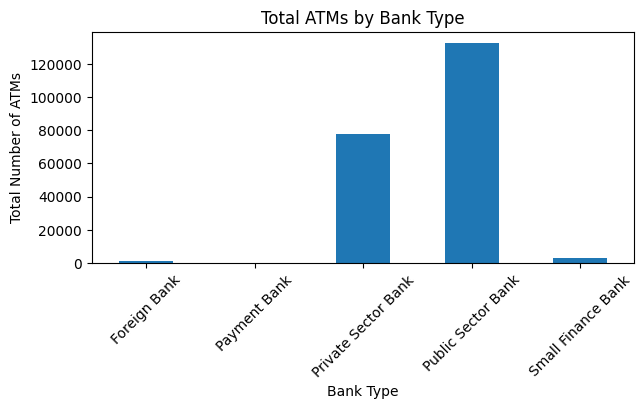

In [ ]:
df.groupby('Bank_Type')['ATMs'].sum().plot(kind='bar', figsize=(7,3))
plt.title('Total ATMs by Bank Type')
plt.xlabel('Bank Type')
plt.ylabel('Total Number of ATMs')
plt.xticks(rotation=45)
plt.show()

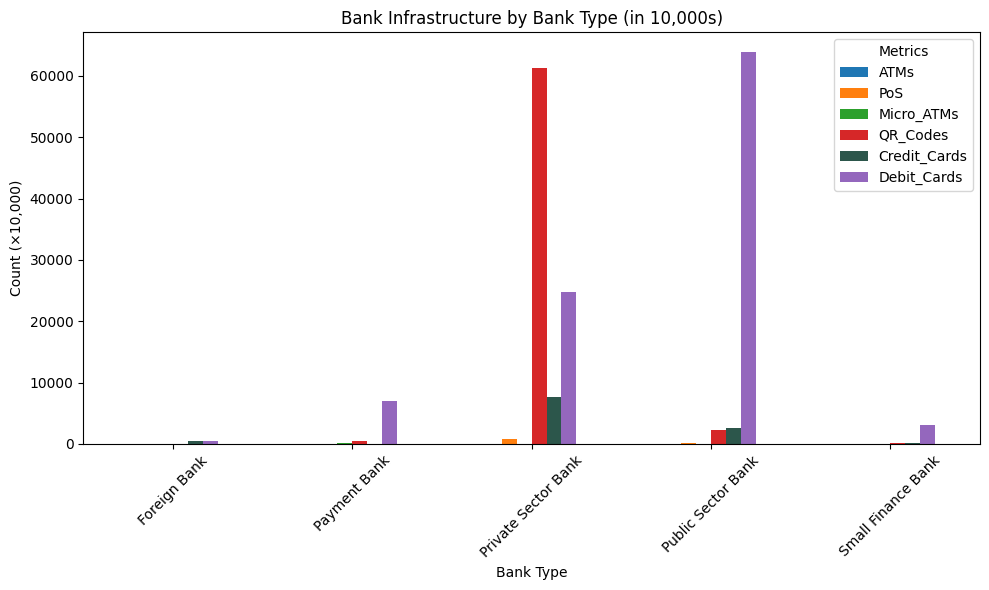

In [ ]:
import matplotlib.pyplot as plt

cols = ['ATMs', 'PoS', 'Micro_ATMs', 'QR_Codes', 'Credit_Cards', 'Debit_Cards']

grouped = df.groupby('Bank_Type')[cols].sum()

# Scale values to 10,000s
grouped_scaled = grouped / 10000

# Define custom colors for each metric
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#2c564b', '#9467bd']

# Plot with custom colors
grouped_scaled.plot(kind='bar', figsize=(10,6), color=colors)
plt.title('Bank Infrastructure by Bank Type (in 10,000s)')
plt.xlabel('Bank Type')
plt.ylabel('Count (×10,000)')
plt.xticks(rotation=45)
plt.legend(title='Metrics', labels=cols)
plt.tight_layout()
plt.show()


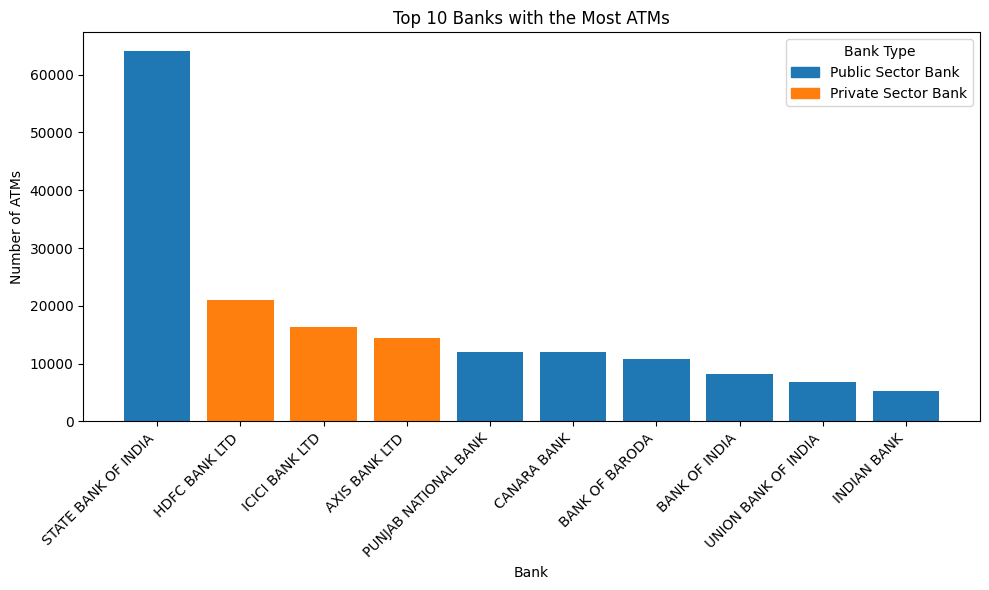

In [ ]:
import matplotlib.pyplot as plt

# Group by Bank to get total ATMs per bank
bank_atms = df.groupby('Bank', as_index=False)['ATMs'].sum()

# Get the corresponding Bank_Type for each Bank (assuming each bank has one type)
bank_types = df[['Bank', 'Bank_Type']].drop_duplicates()

# Merge Bank_Type info into ATM totals
merged = bank_atms.merge(bank_types, on='Bank')

# Select top 10 banks by ATMs
top_10 = merged.sort_values(by='ATMs', ascending=False).head(10)

# Assign unique colors based on Bank_Type
colors = dict(zip(top_10['Bank_Type'].unique(), plt.cm.tab10.colors))
bar_colors = top_10['Bank_Type'].map(colors)

# Plot
plt.figure(figsize=(10,6))
plt.bar(top_10['Bank'], top_10['ATMs'], color=bar_colors)
plt.title('Top 10 Banks with the Most ATMs')
plt.xlabel('Bank')
plt.ylabel('Number of ATMs')
plt.xticks(rotation=45, ha='right')
plt.legend(handles=[plt.Rectangle((0,0),1,1,color=colors[t]) for t in colors],
           labels=colors.keys(), title='Bank Type')
plt.tight_layout()
plt.show()


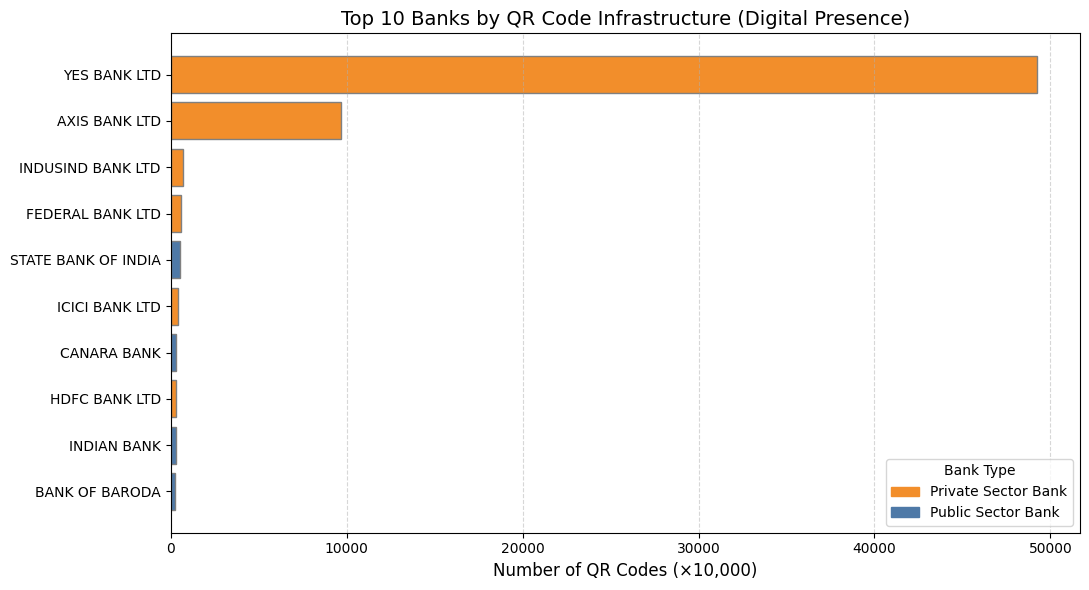

In [ ]:
import matplotlib.pyplot as plt

# Top 10 banks by QR code infrastructure
top10_qr = df.nlargest(10, 'QR_Codes')[['Bank', 'Bank_Type', 'QR_Codes']]

# Define color palette by bank type
color_map = {
    'Public Sector Bank': '#4e79a7',
    'Private Sector Bank': '#f28e2b',
    'Foreign Bank': '#59a14f',
    'Payment Bank': '#e15759',
    'Small Finance Bank': '#b07aa1'
}

# Assign colors based on bank type
colors = top10_qr['Bank_Type'].map(color_map)

# Plot
plt.figure(figsize=(11, 6))
plt.barh(top10_qr['Bank'], top10_qr['QR_Codes'] / 10000, color=colors, edgecolor='gray')

plt.xlabel('Number of QR Codes (×10,000)', fontsize=12)
plt.title('Top 10 Banks by QR Code Infrastructure (Digital Presence)', fontsize=14)
plt.gca().invert_yaxis()

# Legend for visible bank types only
unique_types = top10_qr['Bank_Type'].unique()
plt.legend(
    [plt.Rectangle((0, 0), 1, 1, color=color_map[t]) for t in unique_types],
    unique_types, title='Bank Type', loc='lower right'
)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


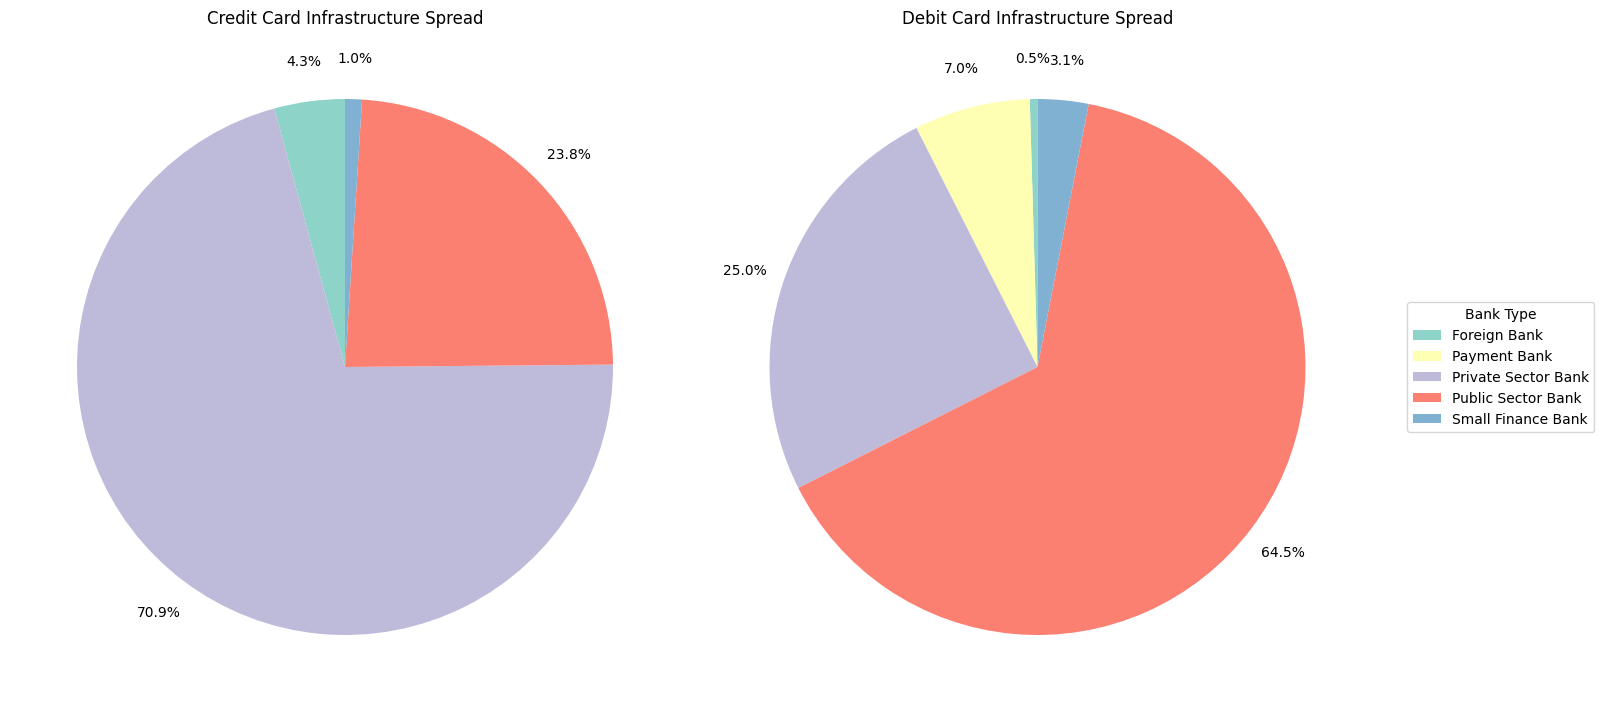

In [ ]:
import matplotlib.pyplot as plt

# Group by Bank_Type and sum Credit_Cards and Debit_Cards
card_spread = df.groupby('Bank_Type')[['Credit_Cards', 'Debit_Cards']].sum()

# Remove rows where both values are 0
card_spread = card_spread[(card_spread['Credit_Cards'] > 0) | (card_spread['Debit_Cards'] > 0)]

# Use the same color palette for both charts
colors = plt.cm.Set3.colors

# Custom function to hide 0%
def autopct_func(pct):
    return ('%1.1f%%' % pct) if pct > 0 else ''

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Pie 1: Credit Cards ---
wedges1, texts1, autotexts1 = axes[0].pie(
    card_spread['Credit_Cards'],
    autopct=autopct_func,
    startangle=90,
    colors=colors,
    pctdistance=1.15,
    textprops={'color': 'black', 'fontsize': 10}
)
axes[0].set_title('Credit Card Infrastructure Spread')

# --- Pie 2: Debit Cards ---
wedges2, texts2, autotexts2 = axes[1].pie(
    card_spread['Debit_Cards'],
    autopct=autopct_func,
    startangle=90,
    colors=colors,
    pctdistance=1.15,
    textprops={'color': 'black', 'fontsize': 10}
)
axes[1].set_title('Debit Card Infrastructure Spread')

# Common legend
fig.legend(
    wedges1,
    card_spread.index,
    title='Bank Type',
    loc='center right',
    bbox_to_anchor=(1.15, 0.5)
)

plt.tight_layout()
plt.show()


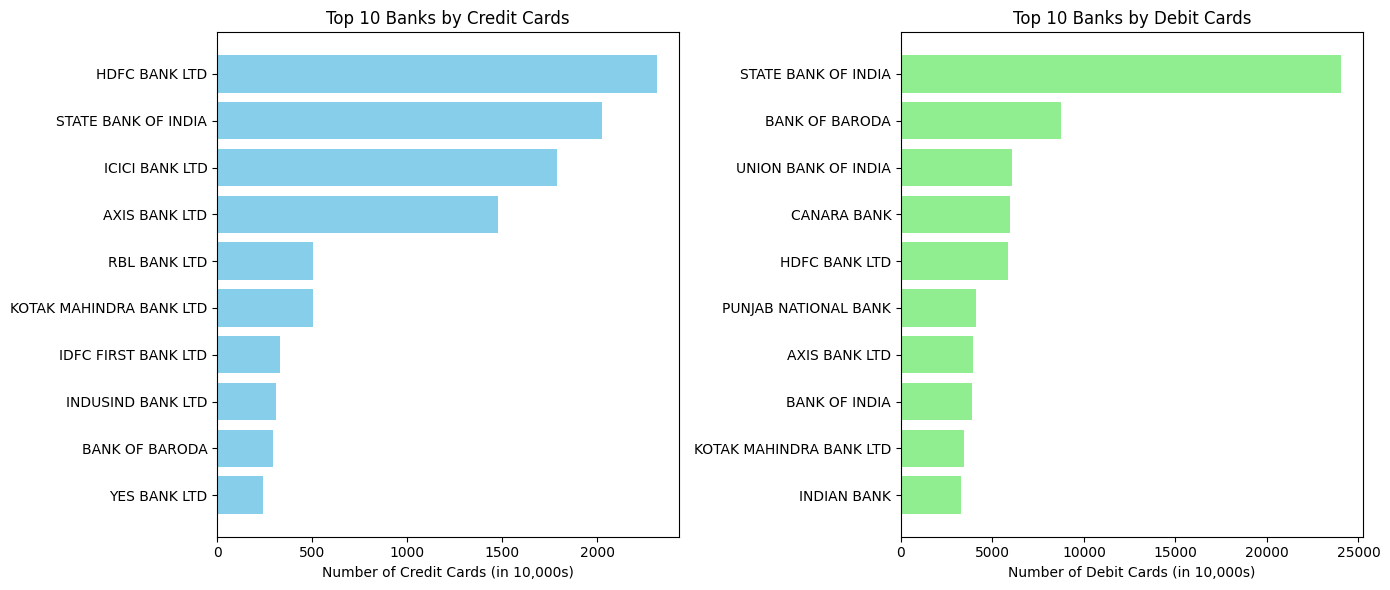

In [ ]:
import matplotlib.pyplot as plt

top_credit = df.nlargest(10, 'Credit_Cards')[['Bank', 'Credit_Cards']]
top_debit = df.nlargest(10, 'Debit_Cards')[['Bank', 'Debit_Cards']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_credit['Bank'], top_credit['Credit_Cards'] / 10000, color='skyblue')
axes[0].set_title('Top 10 Banks by Credit Cards')
axes[0].set_xlabel('Number of Credit Cards (in 10,000s)')
axes[0].invert_yaxis()

axes[1].barh(top_debit['Bank'], top_debit['Debit_Cards'] / 10000, color='lightgreen')
axes[1].set_title('Top 10 Banks by Debit Cards')
axes[1].set_xlabel('Number of Debit Cards (in 10,000s)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


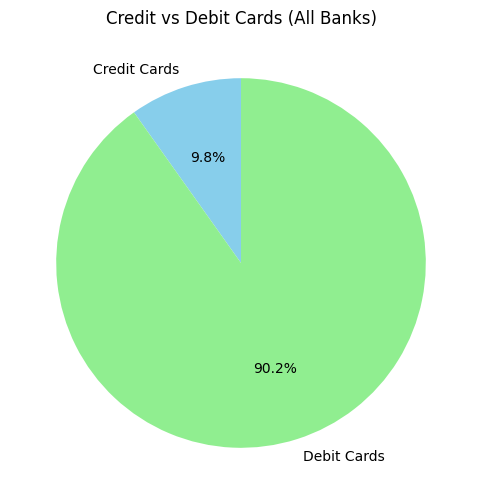

In [ ]:
import matplotlib.pyplot as plt

totals = [
    df['Credit_Cards'].sum(),
    df['Debit_Cards'].sum()
]
labels = ['Credit Cards', 'Debit Cards']

plt.figure(figsize=(6, 6))
plt.pie(totals, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title('Credit vs Debit Cards (All Banks)')
plt.show()


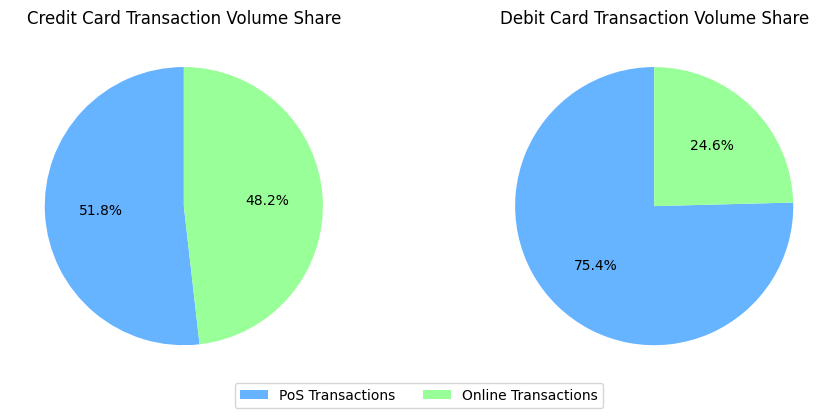

In [ ]:
import matplotlib.pyplot as plt

# Calculate total transaction volumes across all banks
credit_pos_total = df['Credit_PoS_Vol'].sum()
credit_online_total = df['Credit_Online_Vol'].sum()
debit_pos_total = df['Debit_PoS_Vol'].sum()
debit_online_total = df['Debit_Online_Vol'].sum()

# Prepare data
credit_values = [credit_pos_total, credit_online_total]
debit_values = [debit_pos_total, debit_online_total]
labels = ['PoS Transactions', 'Online Transactions']
colors = ['#66b3ff', '#99ff99']  # consistent colors for both charts

# Create side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie(credit_values, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Credit Card Transaction Volume Share')

axes[1].pie(debit_values, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Debit Card Transaction Volume Share')

# Add a single shared legend
fig.legend(labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


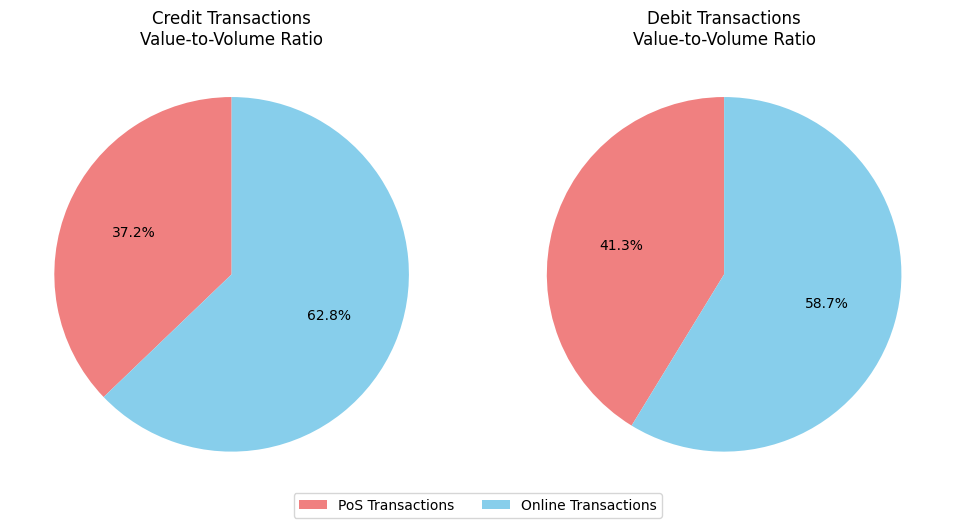

In [ ]:
import matplotlib.pyplot as plt

# Compute value-to-volume ratios
credit_pos_ratio = df['Credit_PoS_Val'].sum() / df['Credit_PoS_Vol'].sum()
credit_online_ratio = df['Credit_Online_Val'].sum() / df['Credit_Online_Vol'].sum()
debit_pos_ratio = df['Debit_PoS_Val'].sum() / df['Debit_PoS_Vol'].sum()
debit_online_ratio = df['Debit_Online_Val'].sum() / df['Debit_Online_Vol'].sum()

# Data for both charts
labels = ['PoS Transactions', 'Online Transactions']
colors = ['lightcoral', 'skyblue']
credit_ratios = [credit_pos_ratio, credit_online_ratio]
debit_ratios = [debit_pos_ratio, debit_online_ratio]

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Credit pie
axes[0].pie(credit_ratios, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Credit Transactions\nValue-to-Volume Ratio')

# Debit pie
axes[1].pie(debit_ratios, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Debit Transactions\nValue-to-Volume Ratio')

# Shared legend
fig.legend(labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.05))

plt.tight_layout()
plt.show()



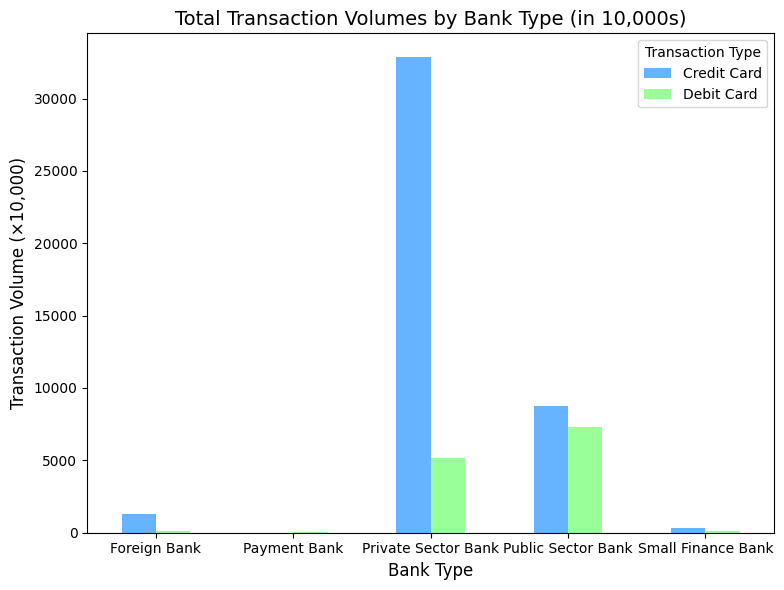

In [ ]:
import matplotlib.pyplot as plt

# Calculate total credit and debit transaction volumes per Bank_Type
grouped = df.groupby('Bank_Type')[['Credit_PoS_Vol', 'Credit_Online_Vol', 'Debit_PoS_Vol', 'Debit_Online_Vol']].sum()

# Compute total credit and debit volumes
grouped['Total_Credit_Vol'] = grouped['Credit_PoS_Vol'] + grouped['Credit_Online_Vol']
grouped['Total_Debit_Vol'] = grouped['Debit_PoS_Vol'] + grouped['Debit_Online_Vol']

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
(grouped[['Total_Credit_Vol', 'Total_Debit_Vol']] / 10000).plot(kind='bar', ax=ax, color=['#66b3ff', '#99ff99'])

ax.set_title('Total Transaction Volumes by Bank Type (in 10,000s)', fontsize=14)
ax.set_xlabel('Bank Type', fontsize=12)
ax.set_ylabel('Transaction Volume (×10,000)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Credit Card', 'Debit Card'], title='Transaction Type')

plt.tight_layout()
plt.show()


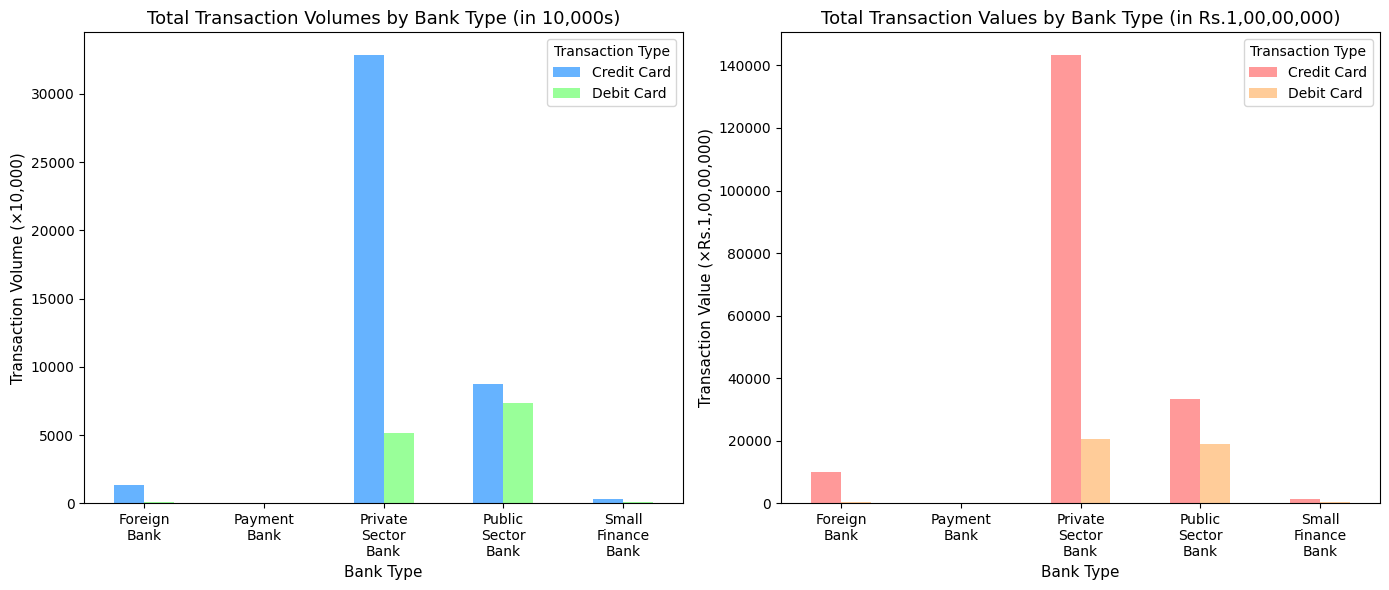

In [ ]:
import matplotlib.pyplot as plt

grouped = df.groupby('Bank_Type')[[
    'Credit_PoS_Vol', 'Credit_Online_Vol', 'Debit_PoS_Vol', 'Debit_Online_Vol',
    'Credit_PoS_Val', 'Credit_Online_Val', 'Debit_PoS_Val', 'Debit_Online_Val'
]].sum()

grouped['Total_Credit_Vol'] = grouped['Credit_PoS_Vol'] + grouped['Credit_Online_Vol']
grouped['Total_Debit_Vol'] = grouped['Debit_PoS_Vol'] + grouped['Debit_Online_Vol']
grouped['Total_Credit_Val'] = grouped['Credit_PoS_Val'] + grouped['Credit_Online_Val']
grouped['Total_Debit_Val'] = grouped['Debit_PoS_Val'] + grouped['Debit_Online_Val']

# Modify x-axis labels to wrap onto two lines
wrapped_labels = [label.replace(' ', '\n') for label in grouped.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

(grouped[['Total_Credit_Vol', 'Total_Debit_Vol']] / 10000).plot(
    kind='bar', ax=axes[0], color=['#66b3ff', '#99ff99']
)
axes[0].set_title('Total Transaction Volumes by Bank Type (in 10,000s)', fontsize=13)
axes[0].set_xlabel('Bank Type', fontsize=11)
axes[0].set_ylabel('Transaction Volume (×10,000)', fontsize=11)
axes[0].set_xticklabels(wrapped_labels, rotation=0)
axes[0].legend(['Credit Card', 'Debit Card'], title='Transaction Type')

(grouped[['Total_Credit_Val', 'Total_Debit_Val']] / 10000).plot(
    kind='bar', ax=axes[1], color=['#ff9999', '#ffcc99']
)
axes[1].set_title('Total Transaction Values by Bank Type (in Rs.1,00,00,000)', fontsize=13)
axes[1].set_xlabel('Bank Type', fontsize=11)
axes[1].set_ylabel('Transaction Value (×Rs.1,00,00,000)', fontsize=11)
axes[1].set_xticklabels(wrapped_labels, rotation=0)
axes[1].legend(['Credit Card', 'Debit Card'], title='Transaction Type')

plt.tight_layout()
plt.show()


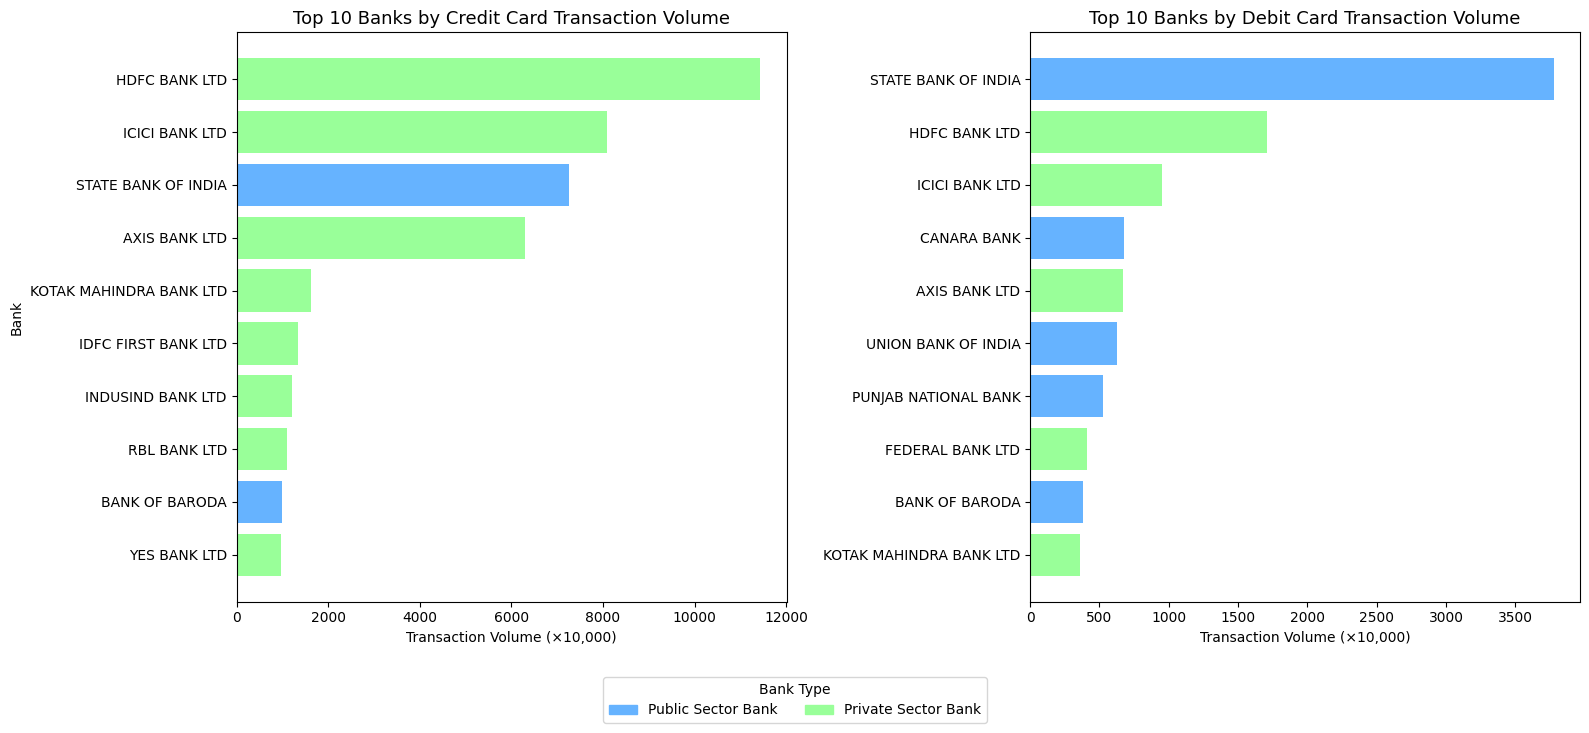

In [ ]:
import matplotlib.pyplot as plt

# Calculate total transaction volumes for each bank
df['Total_Credit_Vol'] = df['Credit_PoS_Vol'] + df['Credit_Online_Vol']
df['Total_Debit_Vol'] = df['Debit_PoS_Vol'] + df['Debit_Online_Vol']

# Get top 10 banks by credit and debit volumes
top_credit = df.nlargest(10, 'Total_Credit_Vol')[['Bank', 'Bank_Type', 'Total_Credit_Vol']]
top_debit = df.nlargest(10, 'Total_Debit_Vol')[['Bank', 'Bank_Type', 'Total_Debit_Vol']]

# Assign colors for bank types
colors = {
    'Public Sector Bank': '#66b3ff',
    'Private Sector Bank': '#99ff99',
    'Foreign Bank': '#ffcc99',
    'Payment Bank': '#ff9999',
    'Small Finance Bank': '#c2c2f0'
}

# Map colors
top_credit['Color'] = top_credit['Bank_Type'].map(colors)
top_debit['Color'] = top_debit['Bank_Type'].map(colors)

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Credit card chart
axes[0].barh(top_credit['Bank'], top_credit['Total_Credit_Vol'] / 10000, color=top_credit['Color'])
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Banks by Credit Card Transaction Volume', fontsize=13)
axes[0].set_xlabel('Transaction Volume (×10,000)')
axes[0].set_ylabel('Bank')

# Debit card chart
axes[1].barh(top_debit['Bank'], top_debit['Total_Debit_Vol'] / 10000, color=top_debit['Color'])
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Banks by Debit Card Transaction Volume', fontsize=13)
axes[1].set_xlabel('Transaction Volume (×10,000)')
axes[1].set_ylabel('')

# Identify only the bank types present in the plotted data
present_types = set(top_credit['Bank_Type']).union(set(top_debit['Bank_Type']))

# Create legend handles for only those types
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in present_types]
labels = list(present_types)

# Add shared legend below plots
fig.legend(handles, labels, title="Bank Type", loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


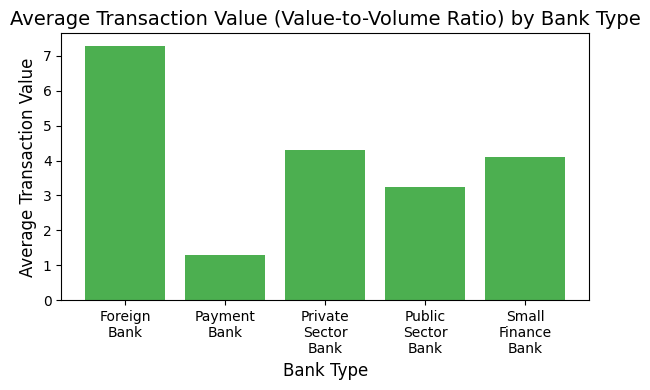

In [ ]:
import matplotlib.pyplot as plt

# Group and sum relevant columns by Bank_Type
grouped = df.groupby('Bank_Type')[[
    'Credit_PoS_Vol', 'Credit_Online_Vol', 'Debit_PoS_Vol', 'Debit_Online_Vol',
    'Credit_PoS_Val', 'Credit_Online_Val', 'Debit_PoS_Val', 'Debit_Online_Val'
]].sum()

# Compute total transaction volumes and values
grouped['Total_Volume'] = (
    grouped['Credit_PoS_Vol'] + grouped['Credit_Online_Vol'] +
    grouped['Debit_PoS_Vol'] + grouped['Debit_Online_Vol']
)
grouped['Total_Value'] = (
    grouped['Credit_PoS_Val'] + grouped['Credit_Online_Val'] +
    grouped['Debit_PoS_Val'] + grouped['Debit_Online_Val']
)

# Calculate Value-to-Volume ratio (average transaction value)
grouped['Value_to_Volume_Ratio'] = grouped['Total_Value'] / grouped['Total_Volume']
grouped = grouped[grouped['Value_to_Volume_Ratio'] > 0]  # remove invalid entries

# Wrap x-axis labels for better readability
wrapped_labels = [label.replace(' ', '\n') for label in grouped.index]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(wrapped_labels, grouped['Value_to_Volume_Ratio'], color='#4CAF50')
plt.title('Average Transaction Value (Value-to-Volume Ratio) by Bank Type', fontsize=14)
plt.xlabel('Bank Type', fontsize=12)
plt.ylabel('Average Transaction Value', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


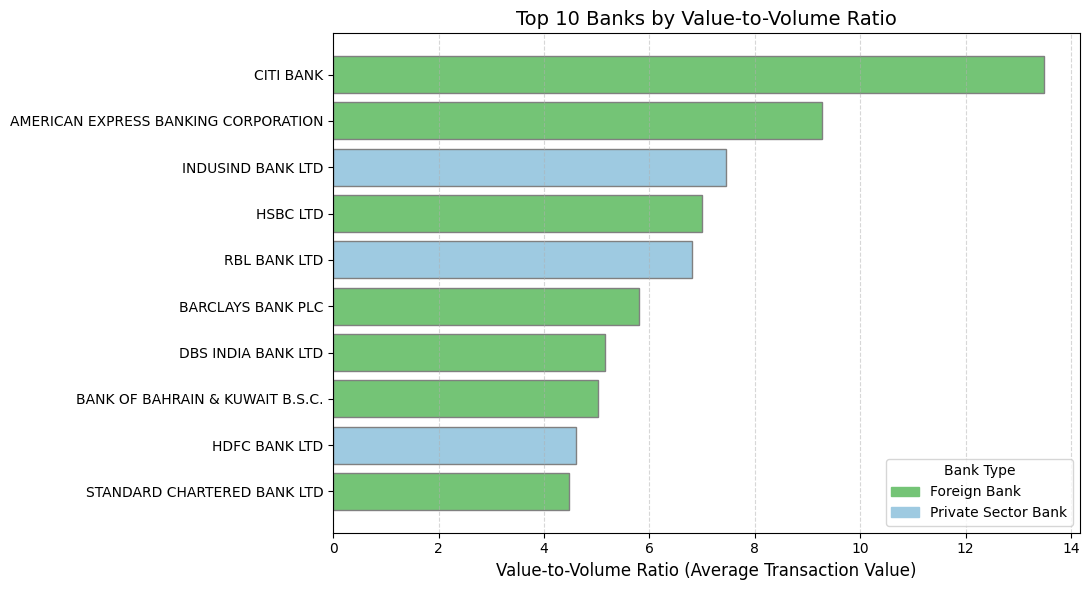

In [ ]:
import matplotlib.pyplot as plt

# Compute total transaction volumes and values per bank
df['Total_Volume'] = (
    df['Credit_PoS_Vol'] + df['Credit_Online_Vol'] +
    df['Debit_PoS_Vol'] + df['Debit_Online_Vol']
)
df['Total_Value'] = (
    df['Credit_PoS_Val'] + df['Credit_Online_Val'] +
    df['Debit_PoS_Val'] + df['Debit_Online_Val']
)

# Calculate Value-to-Volume ratio
df['Value_to_Volume_Ratio'] = df['Total_Value'] / df['Total_Volume']

# Filter valid entries
df_valid = df[df['Value_to_Volume_Ratio'] > 0]

# Get top 10 banks
top10_ratio = df_valid.nlargest(10, 'Value_to_Volume_Ratio')[['Bank', 'Bank_Type', 'Value_to_Volume_Ratio']]

# Define a modern cool-toned pastel palette
color_map = {
    'Public Sector Bank': '#6baed6',   # Soft blue
    'Private Sector Bank': '#9ecae1',  # Light blue
    'Foreign Bank': '#74c476',         # Mint green
    'Payment Bank': '#fdae6b',         # Peach
    'Small Finance Bank': '#c994c7'    # Lavender
}

# Map colors
colors = top10_ratio['Bank_Type'].map(color_map)

# Plot
plt.figure(figsize=(11, 6))
bars = plt.barh(top10_ratio['Bank'], top10_ratio['Value_to_Volume_Ratio'], color=colors, edgecolor='gray')

plt.xlabel('Value-to-Volume Ratio (Average Transaction Value)', fontsize=12)
plt.title('Top 10 Banks by Value-to-Volume Ratio', fontsize=14)
plt.gca().invert_yaxis()

# Dynamic legend for only visible bank types
unique_types = top10_ratio['Bank_Type'].unique()
plt.legend(
    [plt.Rectangle((0, 0), 1, 1, color=color_map[t]) for t in unique_types],
    unique_types, title='Bank Type', loc='lower right'
)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


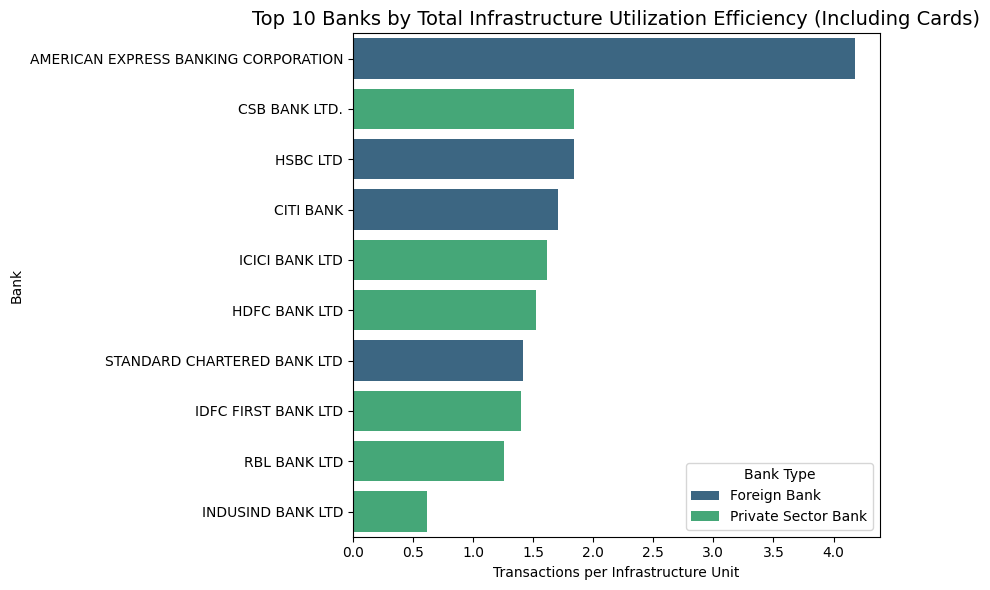

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute infrastructure and transaction metrics
df['Total_Infra'] = df['PoS'] + df['Micro_ATMs'] + df['QR_Codes'] + df['Credit_Cards'] + df['Debit_Cards']
df['Total_Trans_Vol'] = df[['Credit_PoS_Vol', 'Credit_Online_Vol', 'Debit_PoS_Vol', 'Debit_Online_Vol']].sum(axis=1)
df['Infra_Efficiency'] = df['Total_Trans_Vol'] / df['Total_Infra']

# Filter banks with a minimum infrastructure threshold (e.g., 10,000 units)
min_infra_threshold = 10000
filtered_df = df[df['Total_Infra'] >= min_infra_threshold]

# Select top 10 efficient banks from filtered data
top_eff = filtered_df.nlargest(10, 'Infra_Efficiency')[['Bank', 'Infra_Efficiency', 'Bank_Type']]

# Plot
plt.figure(figsize=(9, 6))
sns.barplot(data=top_eff, x='Infra_Efficiency', y='Bank', hue='Bank_Type', palette='viridis')

plt.title('Top 10 Banks by Total Infrastructure Utilization Efficiency (Including Cards)', fontsize=14)
plt.xlabel('Transactions per Infrastructure Unit')
plt.ylabel('Bank')
plt.legend(title='Bank Type')
plt.tight_layout()
plt.show()


Total_Trans_Vol    1.000000
Credit_Cards       0.992240
PoS                0.818312
Debit_Cards        0.659344
QR_Codes           0.080844
Micro_ATMs        -0.040255
Name: Total_Trans_Vol, dtype: float64


/tmp/ipython-input-2778560402.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.index, y=corr.values, palette='coolwarm')


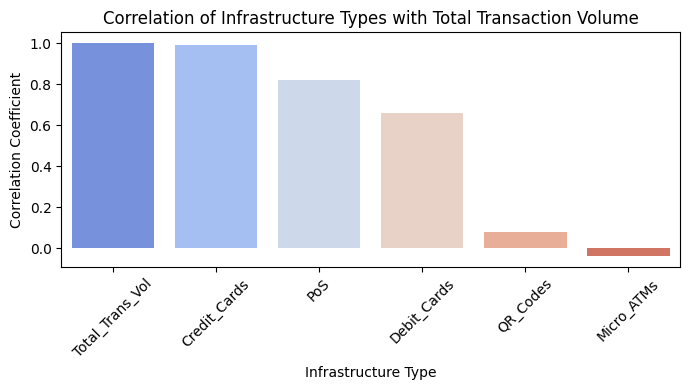

In [ ]:
infra_cols = ['PoS', 'QR_Codes', 'Micro_ATMs', 'Credit_Cards', 'Debit_Cards']
df['Total_Trans_Vol'] = df[['Credit_PoS_Vol', 'Credit_Online_Vol', 'Debit_PoS_Vol', 'Debit_Online_Vol']].sum(axis=1)

corr = df[infra_cols + ['Total_Trans_Vol']].corr()['Total_Trans_Vol'].sort_values(ascending=False)
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.barplot(x=corr.index, y=corr.values, palette='coolwarm')
plt.title('Correlation of Infrastructure Types with Total Transaction Volume')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Infrastructure Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


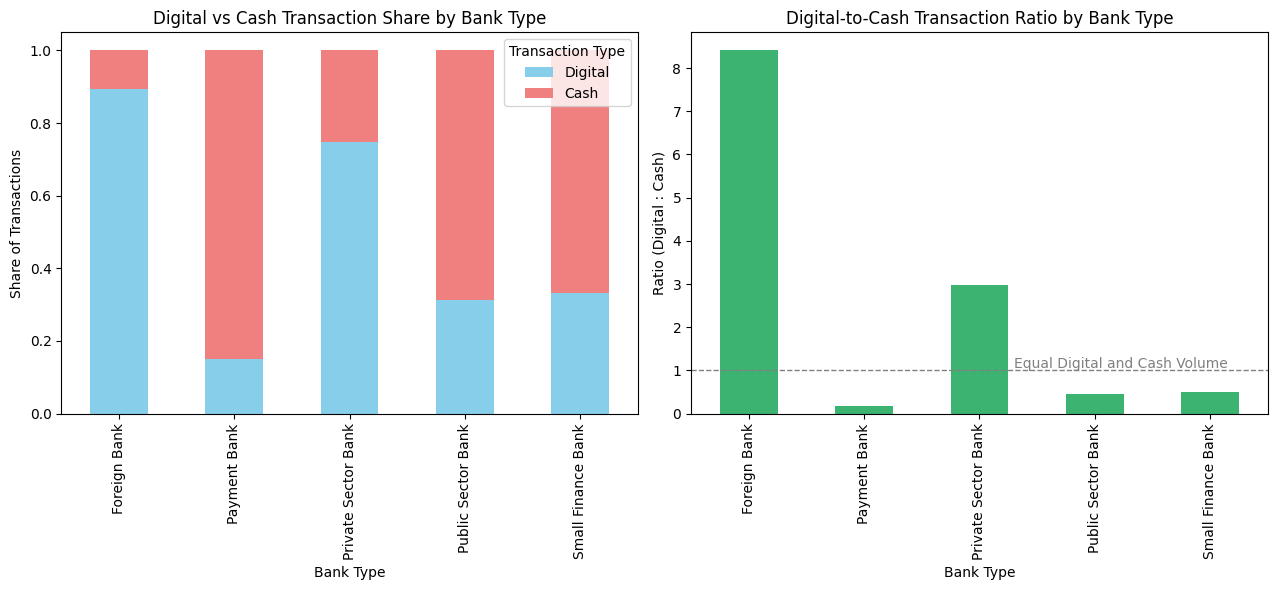

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Digital transactions = PoS + Online (Credit + Debit)
df['Digital_Trans_Vol'] = (
    df['Credit_PoS_Vol'] + df['Credit_Online_Vol'] +
    df['Debit_PoS_Vol'] + df['Debit_Online_Vol']
)

# Cash transactions = Credit + Debit cash withdrawals
df['Cash_Trans_Vol'] = df['Credit_Cash_Vol'] + df['Debit_Cash_Vol']

banktype_focus = df.groupby('Bank_Type')[['Digital_Trans_Vol', 'Cash_Trans_Vol']].sum()

# Compute shares and ratios
banktype_focus['Digital_Share'] = (
    banktype_focus['Digital_Trans_Vol'] /
    (banktype_focus['Digital_Trans_Vol'] + banktype_focus['Cash_Trans_Vol'])
)
banktype_focus['Cash_Share'] = 1 - banktype_focus['Digital_Share']

banktype_focus['Digital_to_Cash_Ratio'] = (
    banktype_focus['Digital_Trans_Vol'] / banktype_focus['Cash_Trans_Vol']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Plot A: Stacked bar of digital vs cash share
banktype_focus[['Digital_Share', 'Cash_Share']].plot(
    kind='bar',
    stacked=True,
    color=['skyblue', 'lightcoral'],
    ax=axes[0]
)
axes[0].set_title('Digital vs Cash Transaction Share by Bank Type')
axes[0].set_ylabel('Share of Transactions')
axes[0].set_xlabel('Bank Type')
axes[0].legend(['Digital', 'Cash'], title='Transaction Type', loc='upper right')

# Plot B: Ratio bar plot
(banktype_focus['Digital_to_Cash_Ratio']).plot(
    kind='bar',
    color='mediumseagreen',
    ax=axes[1]
)
axes[1].set_title('Digital-to-Cash Transaction Ratio by Bank Type')
axes[1].set_ylabel('Ratio (Digital : Cash)')
axes[1].set_xlabel('Bank Type')
axes[1].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[1].text(2.3, 1.05, 'Equal Digital and Cash Volume', color='gray')

plt.tight_layout()
plt.show()


/tmp/ipython-input-655855186.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=atm_util, x='ATM_Utilization', y='Bank_Type', palette='coolwarm')


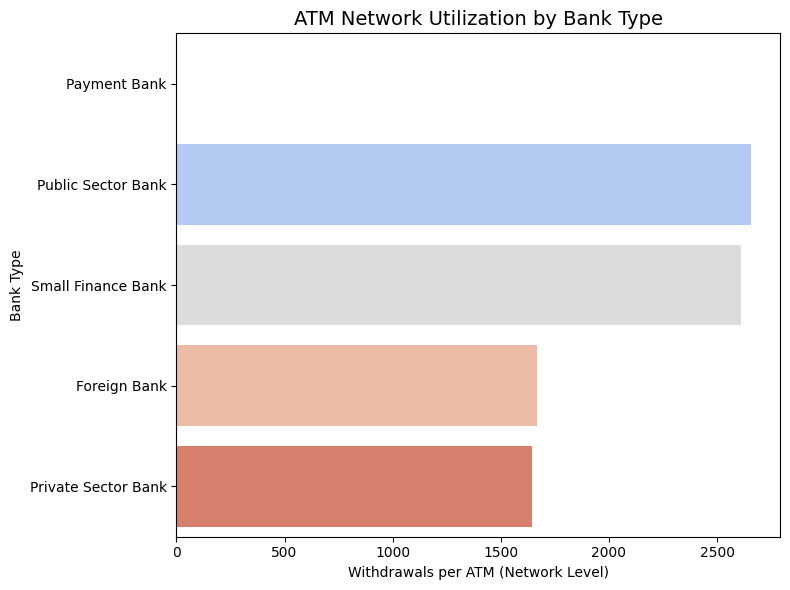

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute total cash withdrawals
df['Total_Cash_Withdrawals'] = df['Credit_Cash_Vol'] + df['Debit_Cash_Vol']

# Group by Bank_Type and sum totals
atm_util = (
    df.groupby('Bank_Type')
      .agg({'Total_Cash_Withdrawals': 'sum', 'ATMs': 'sum'})
      .reset_index()
)

# Compute network-level utilization
atm_util['ATM_Utilization'] = atm_util['Total_Cash_Withdrawals'] / atm_util['ATMs']

# Sort for clarity
atm_util = atm_util.sort_values(by='ATM_Utilization', ascending=False)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=atm_util, x='ATM_Utilization', y='Bank_Type', palette='coolwarm')

plt.title('ATM Network Utilization by Bank Type', fontsize=14)
plt.xlabel('Withdrawals per ATM (Network Level)')
plt.ylabel('Bank Type')
plt.tight_layout()
plt.show()


/tmp/ipython-input-1735081598.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ATM_Utilization'] = filtered_df['Total_Cash_Withdrawals'] / filtered_df['ATMs']


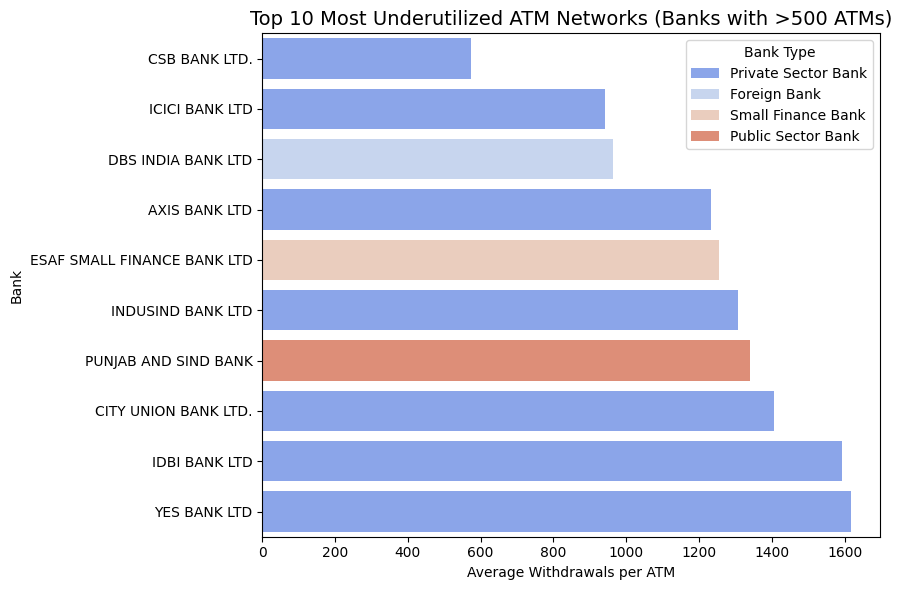

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate total cash withdrawals (credit + debit)
df['Total_Cash_Withdrawals'] = df['Credit_Cash_Vol'] + df['Debit_Cash_Vol']

# Filter banks with > 500 ATMs
filtered_df = df[df['ATMs'] > 500]

# Compute ATM utilization = withdrawals per ATM
filtered_df['ATM_Utilization'] = filtered_df['Total_Cash_Withdrawals'] / filtered_df['ATMs']

# Select 10 most underutilized banks
underutilized = filtered_df.nsmallest(10, 'ATM_Utilization')[['Bank', 'Bank_Type', 'ATM_Utilization', 'ATMs']]

# Plot
plt.figure(figsize=(9, 6))
sns.barplot(data=underutilized, x='ATM_Utilization', y='Bank', hue='Bank_Type', palette='coolwarm')

plt.title('Top 10 Most Underutilized ATM Networks (Banks with >500 ATMs)', fontsize=14)
plt.xlabel('Average Withdrawals per ATM')
plt.ylabel('Bank')
plt.legend(title='Bank Type', loc='upper right')
plt.tight_layout()
plt.show()
